# Canny Edge Detection

Canny는 단순히 한 번의 커널 연산으로 끝나는 필터가 아니라, 다음 단계를 순차적으로 수행하는 다단계 에지 검출 알고리즘이다.

1. Gaussian Blur로 노이즈 제거
2. Sobel 연산으로 기울기 계산
3. Non-Maximum Suppression으로 에지 얇게 만들기
4. Double Threshold로 강한 에지와 약한 에지 구분
5. Hysteresis로 최종 에지 연결

OpenCV에서는 이 전체 과정을 cv2.Canny() 하나로 수행할 수 있다.
그러면 너무 쉬운데...



## 3. 핵심 파라미터

```python
edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)
```

Canny Edge Detection에서 핵심 파라미터는 `threshold1`과 `threshold2`이다.

- `threshold1`: 낮은 임계값
- `threshold2`: 높은 임계값

픽셀의 기울기 크기를 $G(x,y)$, 낮은 임계값을 $T_{\text{low}}$, 높은 임계값을 $T_{\text{high}}$라고 하자.

---

### `threshold1`: 낮은 임계값

`threshold1`은 약한 에지 후보를 구분하는 낮은 임계값이다.

기울기 크기 $G(x,y)$가 낮은 임계값 $T_{\text{low}}$보다 작으면 에지가 아닌 것으로 판단하여 제거한다.

$$
G(x,y) < T_{\text{low}}
$$

기울기 크기가 낮은 임계값 이상이면서 높은 임계값보다 작으면 약한 에지 후보로 분류한다.

$$
T_{\text{low}} \leq G(x,y) < T_{\text{high}}
$$

약한 에지는 주변의 강한 에지와 연결된 경우에만 최종 에지로 유지된다.

---

### `threshold2`: 높은 임계값

`threshold2`는 강한 에지를 구분하는 높은 임계값이다.

기울기 크기가 높은 임계값 $T_{\text{high}}$ 이상이면 해당 픽셀을 강한 에지로 판단한다.

$$
G(x,y) \geq T_{\text{high}}
$$

강한 에지는 최종 결과에 직접 포함된다. 또한 주변에 연결된 약한 에지를 유지할지를 판단하는 기준으로 사용된다.

---

### 임계값에 따른 에지 분류

일반적인 경향은 다음과 같다.

| 임계값 | 결과                   |
| --- | -------------------- |
| 낮음  | 약한 경계와 노이즈까지 많이 검출   |
| 중간  | 주요 구조와 세부 경계가 적절히 검출 |
| 높음  | 강한 경계만 남고 약한 에지는 제거  |


---

### 임계값의 일반적인 비율

일반적으로 높은 임계값은 낮은 임계값의 약 2배에서 3배 정도로 설정하는 경우가 많다.

$$
T_{\text{high}} \approx 2T_{\text{low}}
$$

또는

$$
T_{\text{high}} \approx 3T_{\text{low}}
$$

이를 범위로 표현하면 다음과 같다.

$$
2T_{\text{low}}
\leq
T_{\text{high}}
\leq
3T_{\text{low}}
$$

하지만 이는 절대적인 규칙이 아니다. 이미지의 밝기, 대비, 노이즈 수준과 검출하려는 구조의 특성에 따라 두 임계값을 조정해야 한다.

### Gaussian Blur 유무 비교

Canny 내부에도 Gaussian smoothing 단계가 있지만, OpenCV의 cv2.Canny()를 사용할 때는 직접 blur를 먼저 적용하여 노이즈 수준을 조정하는 경우가 많다.
Gaussian Blur를 적용하면 작은 질감과 센서 노이즈에 의한 에지가 줄어든다. 반면 blur가 너무 강하면 문틀, 벽 경계, 얇은 선과 같은 중요한 구조도 사라질 수 있다.


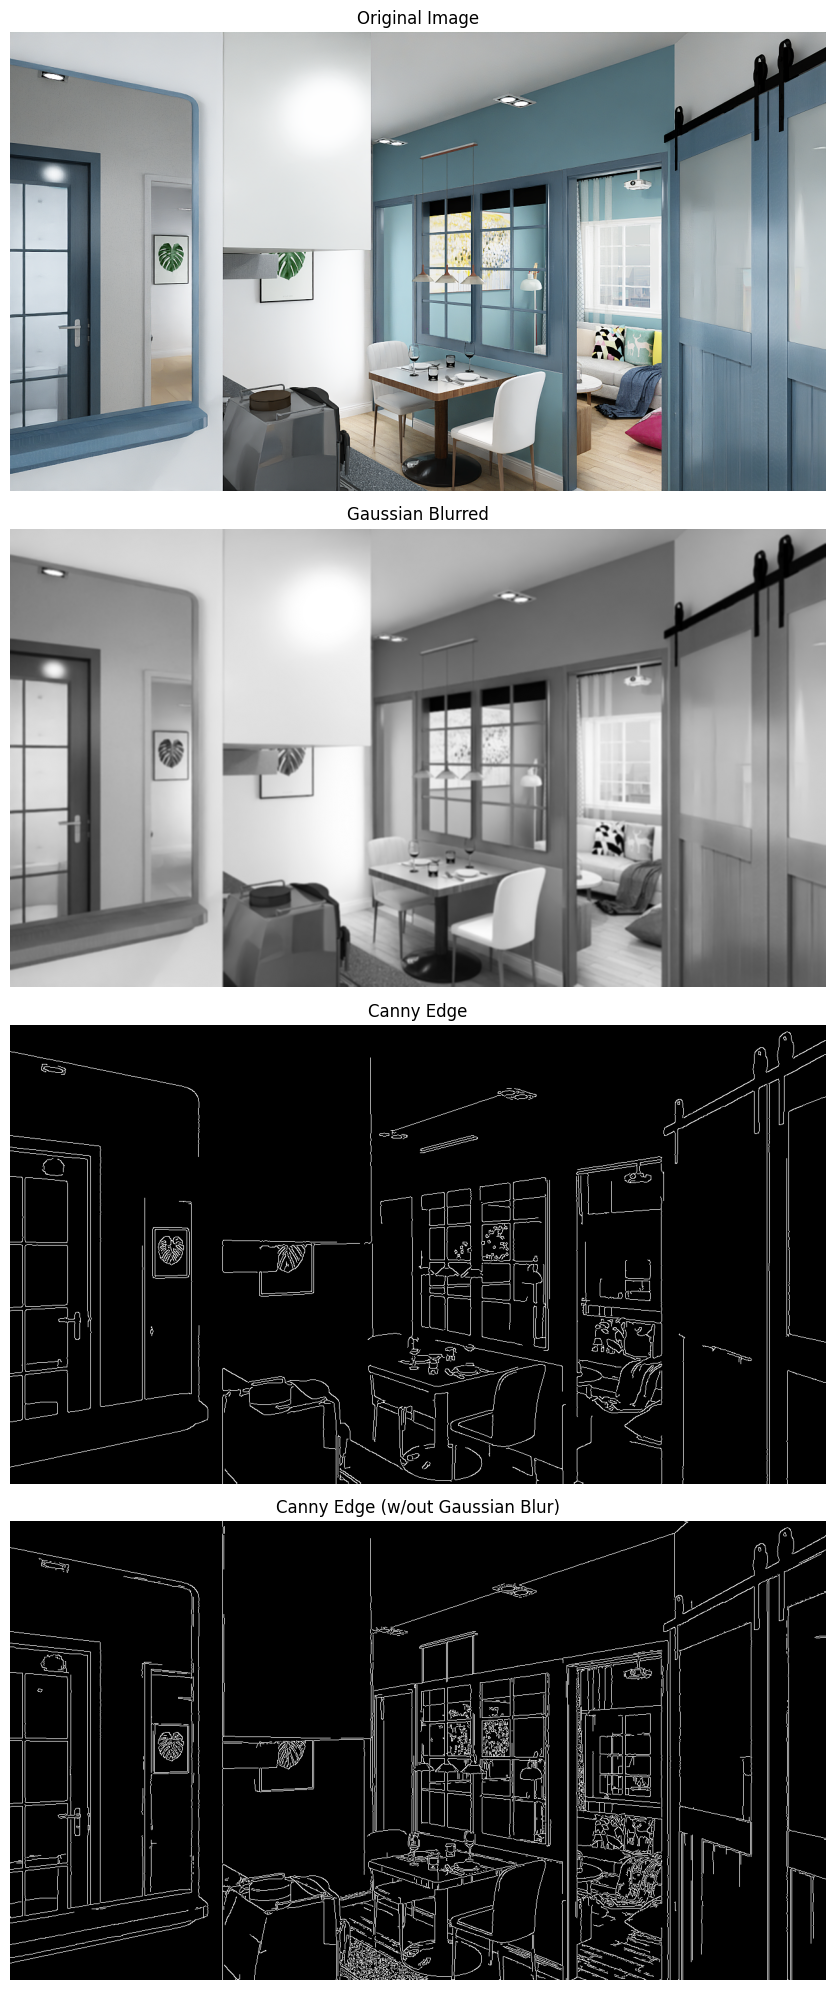

In [11]:
import cv2
import matplotlib.pyplot as plt

# 이미지 불러오기
image = cv2.imread("./data/rgb_rawlight.png")

# OpenCV는 BGR 순서이므로 RGB로 변환
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale 변환
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
blurred_g = gray

# Canny Edge Detection
edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150
)

edges_gray = cv2.Canny(
    blurred_g,
    threshold1=50,
    threshold2=150
)

# 결과 출력
plt.figure(figsize=(15, 20))

plt.subplot(4, 1, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(4, 1, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(4, 1, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(4, 1, 4)
plt.imshow(edges_gray, cmap="gray")
plt.title("Canny Edge (w/out Gaussian Blur)")
plt.axis("off")

plt.tight_layout()
plt.show()

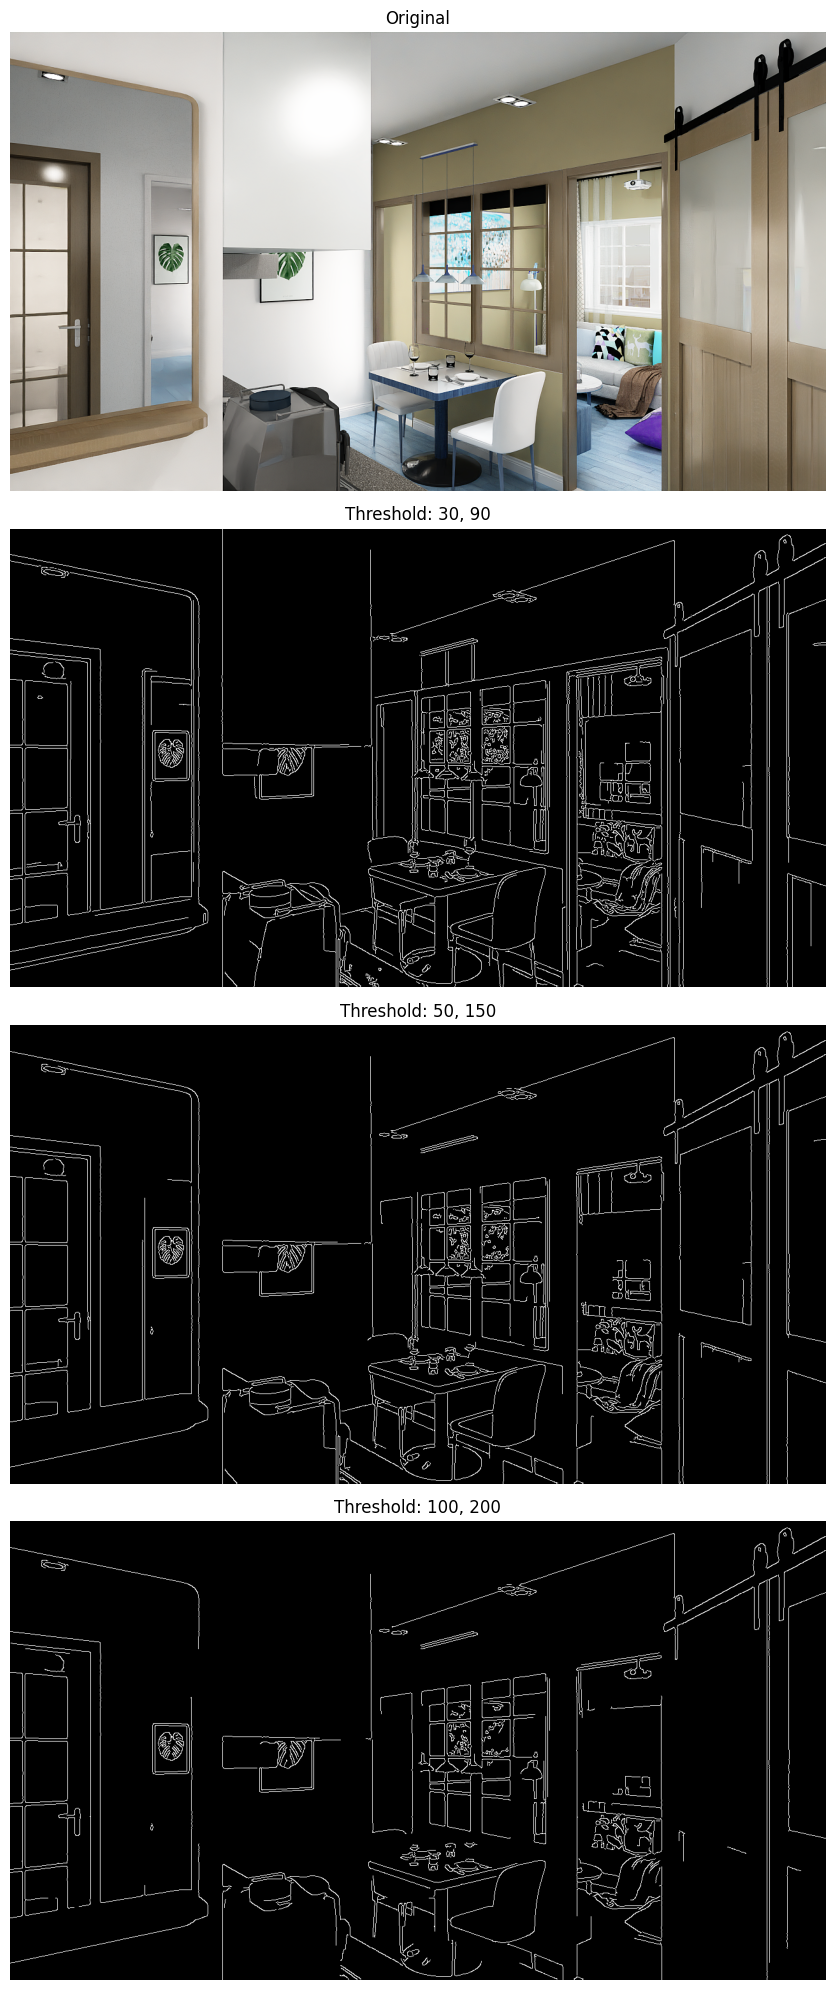

In [16]:
blurred = cv2.GaussianBlur(image, (5, 5), 1.4)

edges_low = cv2.Canny(blurred, 30, 90)
edges_middle = cv2.Canny(blurred, 50, 150)
edges_high = cv2.Canny(blurred, 100, 200)

plt.figure(figsize=(16, 20))

plt.subplot(4, 1, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(4, 1, 2)
plt.imshow(edges_low, cmap="gray")
plt.title("Threshold: 30, 90")
plt.axis("off")

plt.subplot(4, 1, 3)
plt.imshow(edges_middle, cmap="gray")
plt.title("Threshold: 50, 150")
plt.axis("off")

plt.subplot(4, 1, 4)
plt.imshow(edges_high, cmap="gray")
plt.title("Threshold: 100, 200")
plt.axis("off")

plt.tight_layout()
plt.show()

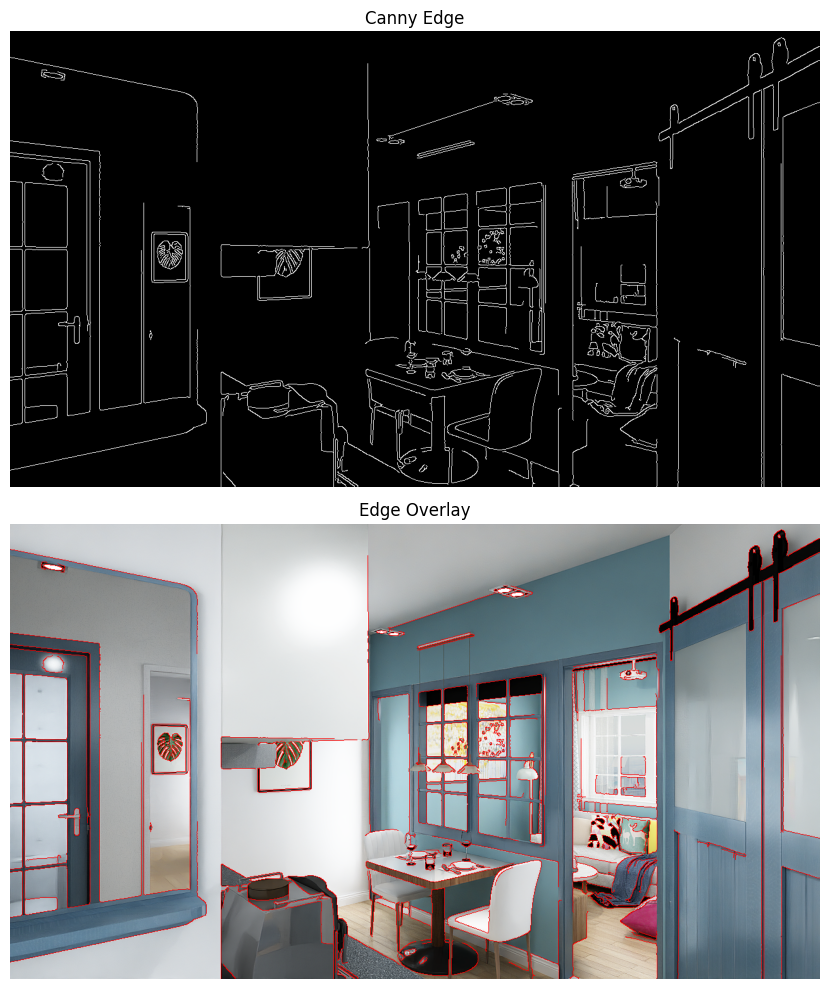

In [20]:
#원본에 오버레이를 해보면 엣지가 잘 검출되었는지 확인할 수 있습니다.

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
edges = cv2.Canny(blurred, 50, 150)

overlay = image_rgb.copy()

# 에지 위치를 빨간색으로 표시
overlay[edges > 0] = [255, 0, 0]

plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(overlay)
plt.title("Edge Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Canny에서 Sobel 기울기 계산

Canny 내부에서는 일반적으로 Sobel 연산으로 수평·수직 기울기를 계산한다.

$$
G_x = I * S_x
$$

$$
G_y = I * S_y
$$

여기서 \(I\)는 입력 이미지이고, \(*\)는 컨볼루션 연산을 의미한다.

대표적인 Sobel 커널은 다음과 같다.

$$
S_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$
S_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

기울기 크기는 다음처럼 계산된다.

$$
G = \sqrt{G_x^2 + G_y^2}
$$

기울기 방향은 다음과 같다.

$$
\theta = \tan^{-1}\left(\frac{G_y}{G_x}\right)
$$

OpenCV에서는 `L2gradient=True`를 설정하면 위의 유클리드 거리 방식으로 기울기 크기를 계산한다.

```python
edges = cv2.Canny(
    blurred,
    threshold1=50,
    threshold2=150,
    apertureSize=3,
    L2gradient=True
)
```

`L2gradient=False`일 때는 더 빠른 근사식을 사용한다.

$$
G \approx |G_x| + |G_y|
$$

### 간단한 숫자 예시

어떤 픽셀에서 Sobel 연산 결과가 다음과 같다고 가정하자.

$$
G_x = 3
$$

$$
G_y = 4
$$

이때 기울기 크기는 다음과 같다.

$$
G = \sqrt{G_x^2 + G_y^2}
$$

$$
G = \sqrt{3^2 + 4^2}
$$

$$
G = \sqrt{9 + 16}
$$

$$
G = 5
$$

기울기 방향은 다음과 같다.

$$
\theta = \tan^{-1}\left(\frac{G_y}{G_x}\right)
$$

$$
\theta = \tan^{-1}\left(\frac{4}{3}\right)
$$

$$
\theta \approx 53.1^\circ
$$

따라서 이 픽셀의 기울기 크기는 약 $5$, 기울기 방향은 약 $53.1^\circ$이다.